In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("C:\study\PROJECTS\churn prediction\Telecom Churn Dataset.csv")
df = pd.DataFrame(data)

In [3]:
df.head()

,ID,Gender,SeniorCitizen,Married,Tenure,PhoneService,MultipleLines,InternetService,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Female,0,Yes,1,No,No,DSL,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,1,Male,0,No,34,Yes,No,DSL,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,2,Male,0,No,2,Yes,No,DSL,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,3,Male,0,No,45,No,No,DSL,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,4,Female,0,No,2,Yes,No,Fiber optic,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.isnull().sum()

ID                  0
Gender              0
SeniorCitizen       0
Married             0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                126 non-null    int64  
 1   Gender            126 non-null    object 
 2   SeniorCitizen     126 non-null    int64  
 3   Married           126 non-null    object 
 4   Tenure            126 non-null    int64  
 5   PhoneService      126 non-null    object 
 6   MultipleLines     126 non-null    object 
 7   InternetService   126 non-null    object 
 8   TechSupport       126 non-null    object 
 9   StreamingTV       126 non-null    object 
 10  StreamingMovies   126 non-null    object 
 11  Contract          126 non-null    object 
 12  PaperlessBilling  126 non-null    object 
 13  PaymentMethod     126 non-null    object 
 14  MonthlyCharges    126 non-null    float64
 15  TotalCharges      126 non-null    float64
 16  Churn             126 non-null    object 
dt

In [8]:
mat = np.array([[[1, 2, 3], [2, 3, 4]], [[5, 6, 7], [8, 9, 0]], [[1, 4, 3], [5, 6, 8]]])
mat.shape

(3, 2, 3)

In [12]:
df['Contract_binary'] = df['Contract'].apply(lambda x: 1 if x == 'Month-to-month' else 0)
df

,ID,Gender,SeniorCitizen,Married,Tenure,PhoneService,MultipleLines,InternetService,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_binary
0,0,Female,0,Yes,1,No,No,DSL,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1
1,1,Male,0,No,34,Yes,No,DSL,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,2,Male,0,No,2,Yes,No,DSL,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,3,Male,0,No,45,No,No,DSL,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,4,Female,0,No,2,Yes,No,Fiber optic,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,121,Female,0,Yes,65,Yes,Yes,Fiber optic,Yes,Yes,No,Two year,Yes,Credit card (automatic),99.05,6416.70,No,0
122,122,Male,0,No,3,Yes,No,No,No,No,No,One year,No,Mailed check,19.60,61.35,No,0
123,123,Male,0,No,1,Yes,No,DSL,No,No,No,Month-to-month,Yes,Electronic check,45.65,45.65,Yes,1
124,124,Male,0,No,30,Yes,No,DSL,No,Yes,No,One year,No,Credit card (automatic),64.50,1929.95,No,0


([<matplotlib.patches.Wedge at 0x2318f9a46e0>,
 [Text(-0.08220322789841819, 1.0969241675353318, '66'),
  Text(0.08220332379457805, -1.096924160348893, '60')])

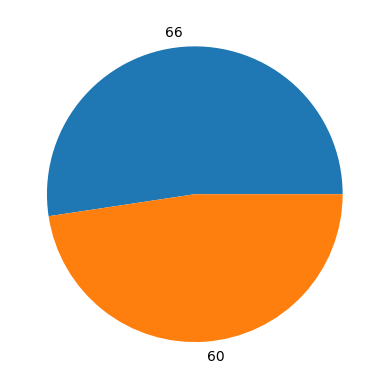

In [13]:
t = df['Contract_binary'].value_counts()
plt.pie(t,labels=t)

In [14]:
df = df.drop(columns=['ID'])

In [15]:
binary_cols = ['Gender', 'Married', 'PhoneService', 'PaperlessBilling','MultipleLines','TechSupport','StreamingTV','StreamingMovies']
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [16]:
df.head()

,Gender,SeniorCitizen,Married,Tenure,PhoneService,MultipleLines,InternetService,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Contract_binary
0,0,0,1,1,0,0,DSL,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,No,1
1,1,0,0,34,1,0,DSL,0,0,0,One year,0,Mailed check,56.95,1889.50,No,0
2,1,0,0,2,1,0,DSL,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,Yes,1
3,1,0,0,45,0,0,DSL,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,No,0
4,0,0,0,2,1,0,Fiber optic,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,Yes,1


In [17]:
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'])

In [18]:
df.head()

,Gender,SeniorCitizen,Married,Tenure,PhoneService,MultipleLines,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,0,0,0,0,0,1,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,34,1,0,0,0,0,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,2,1,0,0,0,0,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,45,0,0,1,0,0,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,2,1,0,0,0,0,1,...,False,True,False,True,False,False,False,False,True,False


In [19]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()


In [20]:
X = df.drop(columns=['Churn'])
y = df['Churn']

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC AUC Score:', roc_auc_score(y_test, y_probs))

              precision    recall  f1-score   support

          No       0.83      0.83      0.83        18
         Yes       0.62      0.62      0.62         8

    accuracy                           0.77        26
   macro avg       0.73      0.73      0.73        26
weighted avg       0.77      0.77      0.77        26

ROC AUC Score: 0.7708333333333334



Classification Report:
               precision    recall  f1-score   support

          No       0.84      0.89      0.86        18
         Yes       0.71      0.62      0.67         8

    accuracy                           0.81        26
   macro avg       0.78      0.76      0.77        26
weighted avg       0.80      0.81      0.80        26

ROC AUC Score: 0.7395833333333334


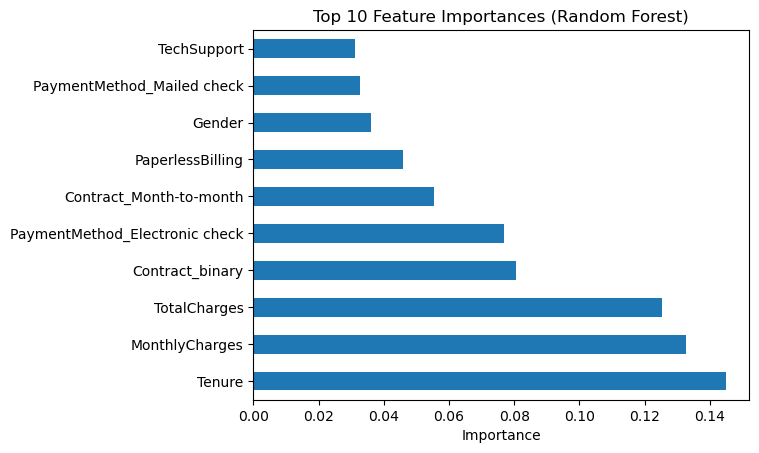

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
y_probs = rf_model.predict_proba(X_test)[:, 1]


print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_probs))

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()